In [2]:
# Exploratory Data Analysis (EDA) Script for Bugra Akkus my other 2 firend will upload with their name
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
df = pd.read_csv('Phishing_URL_ds_5percent_missing_train.csv')

1- Domain identifiers
TLD (Top Level Doamin) the suffix of the domain phishing sites often use cheap or obcoure TLDs.
Is DoaminIP returns 1 if domain is an IP address instead of a name. Legitimate public sites rarely use raw IPs.
2- Lexical Features ( URl String Analysis)
these analyze looking to length of the URL. phsishing website generally have long and random URL.
URL

*univariate analyses*

In [3]:
#split columns by data type
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

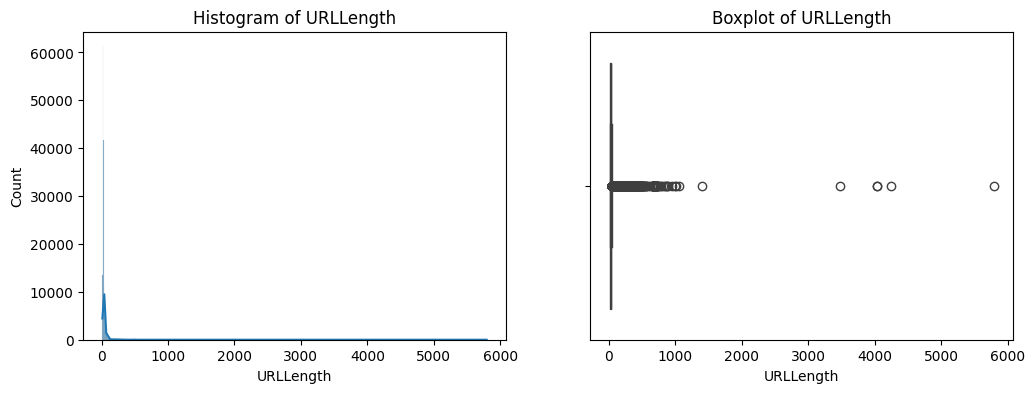

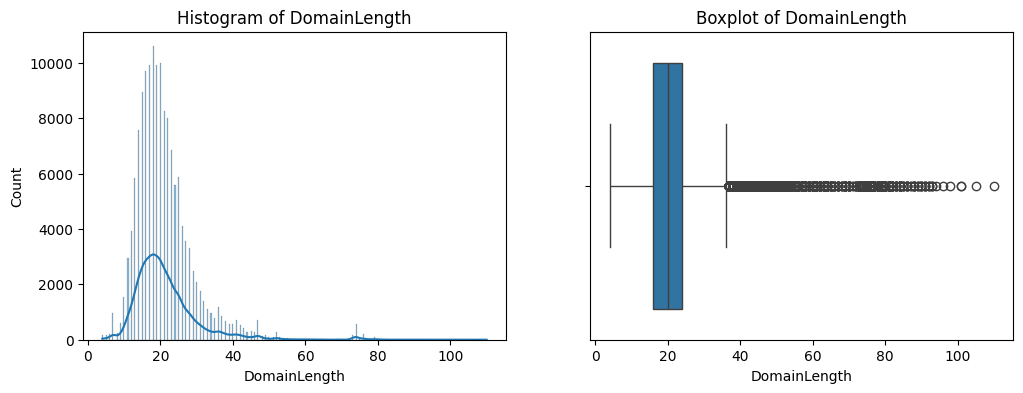

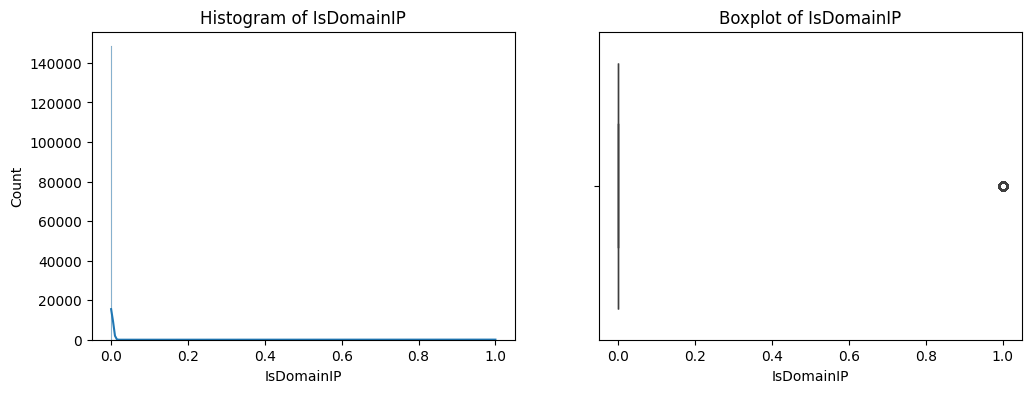

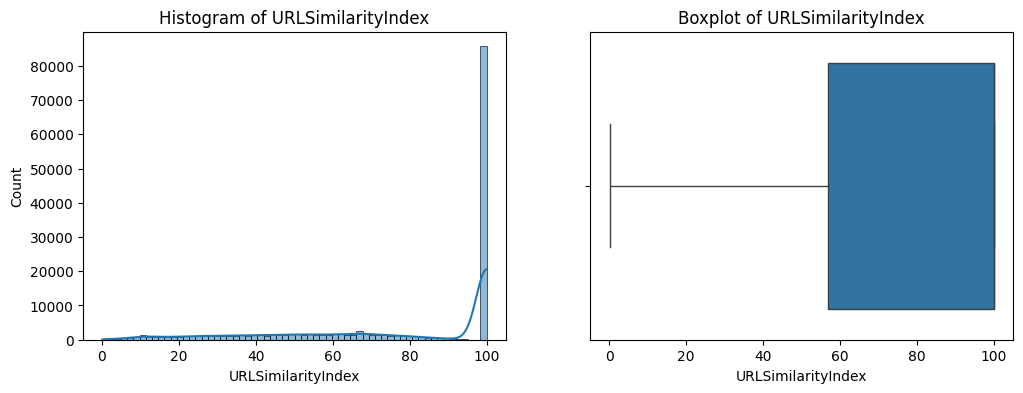

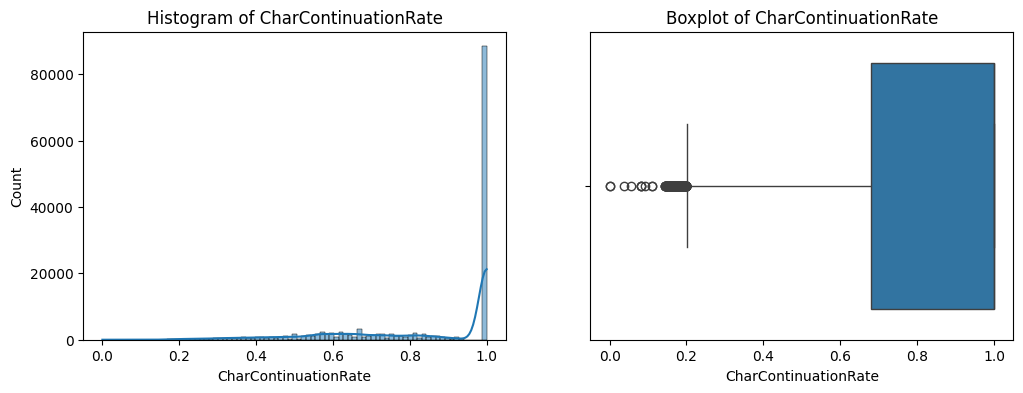

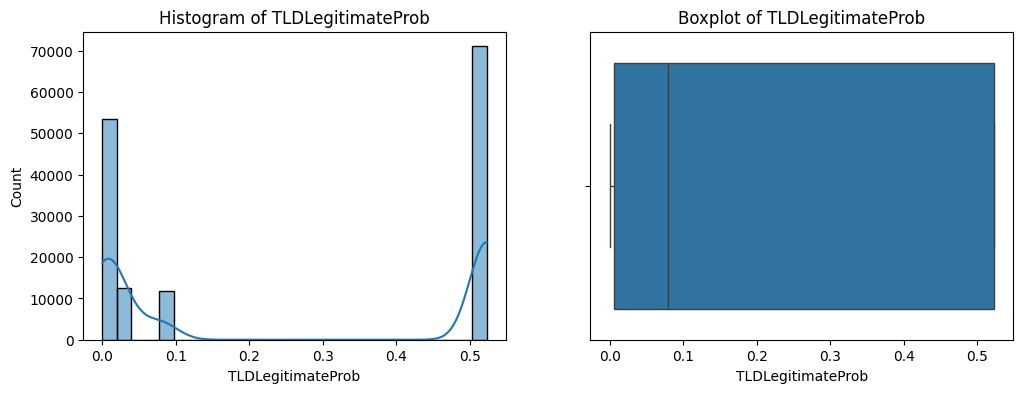

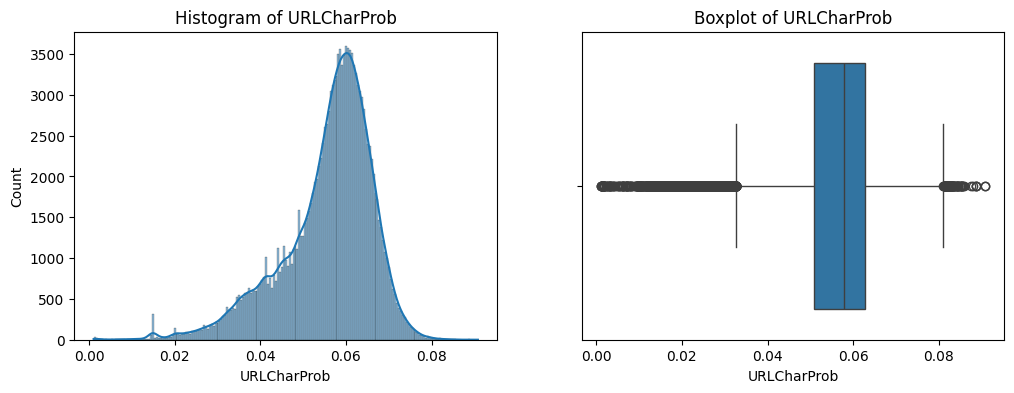

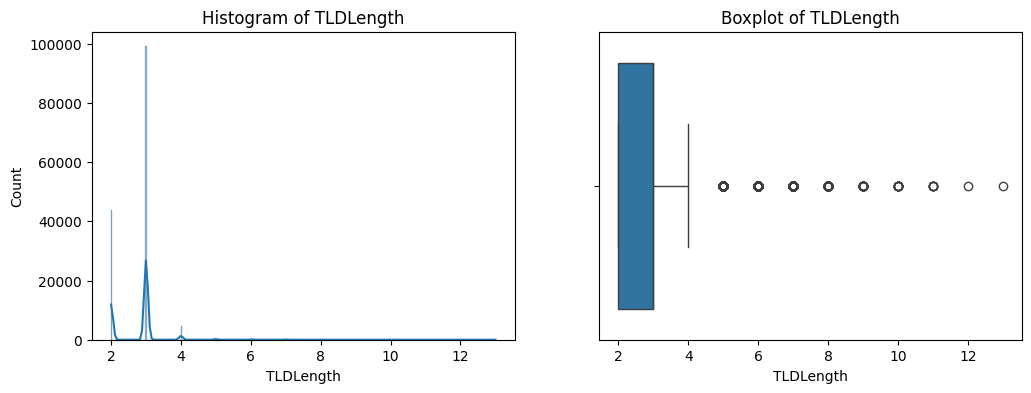

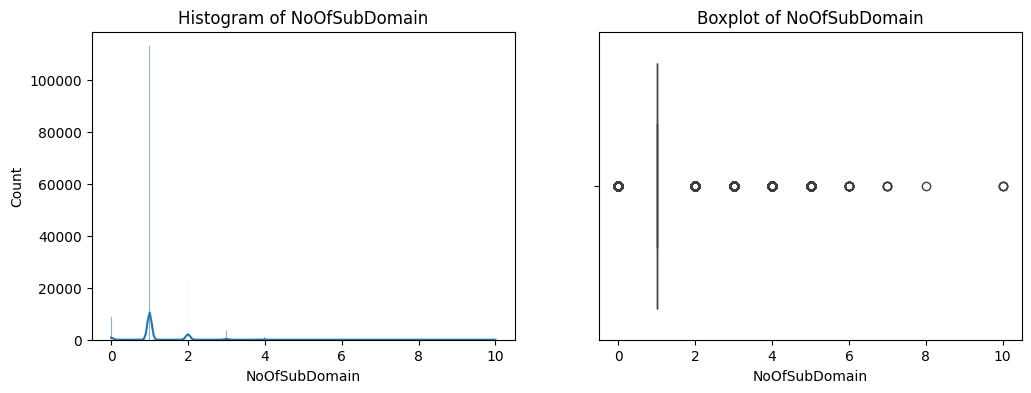

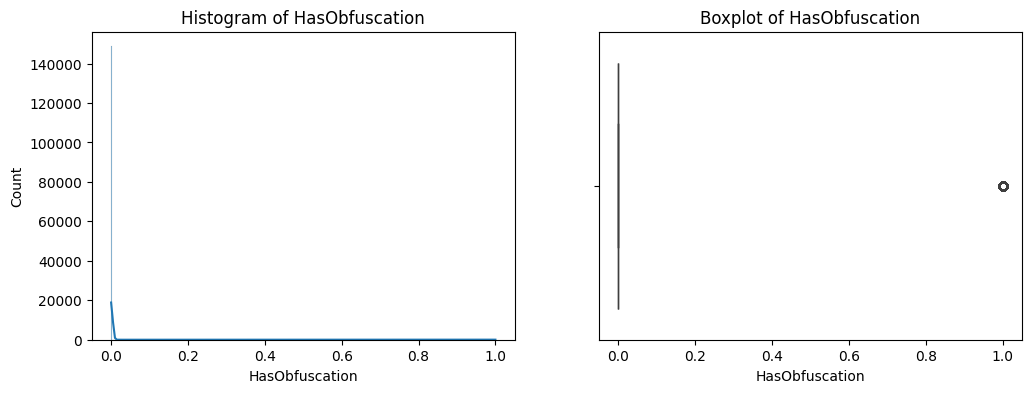

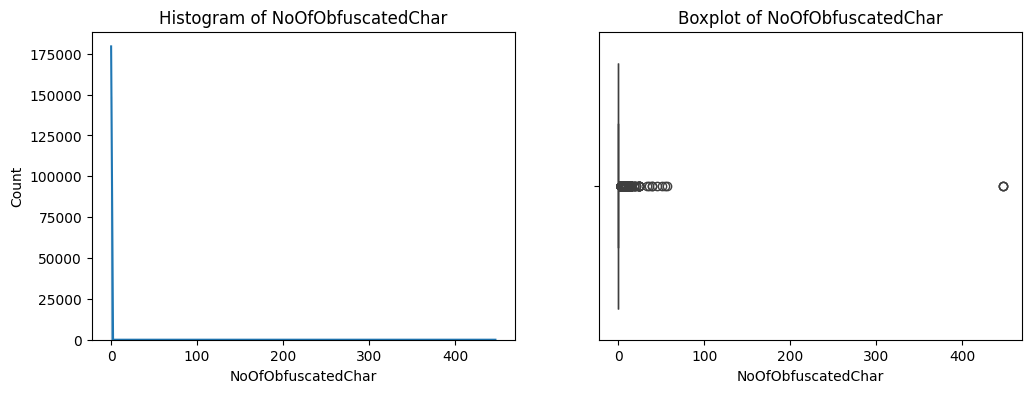

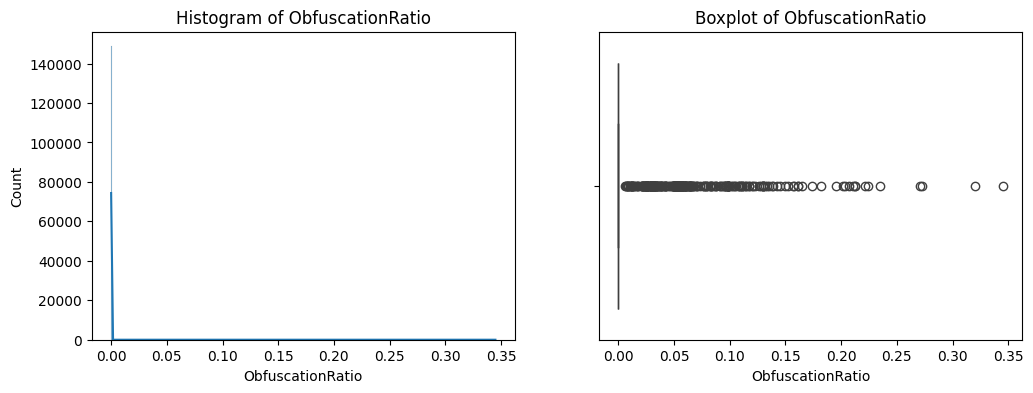

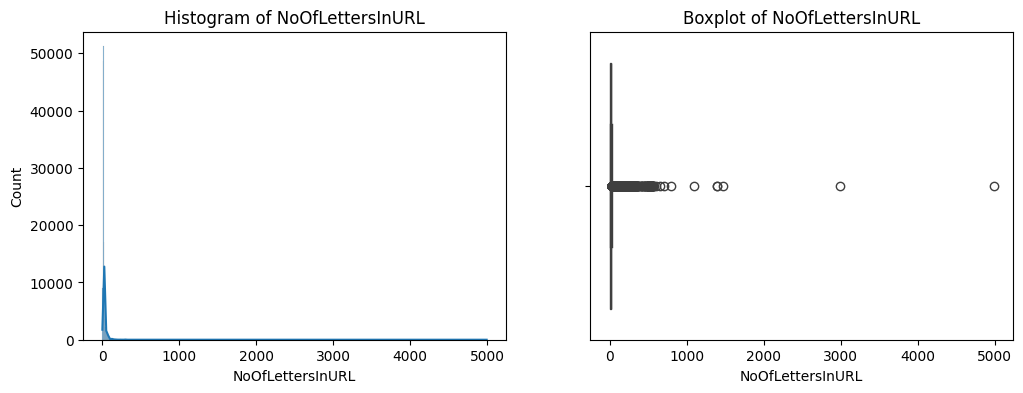

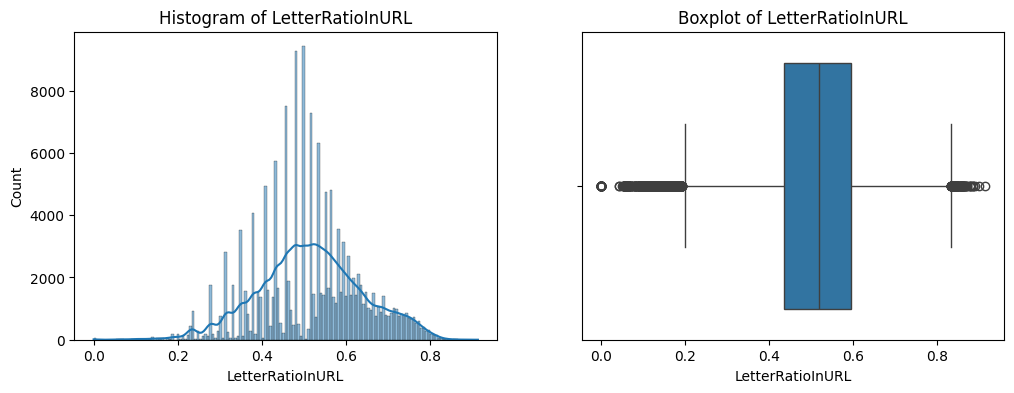

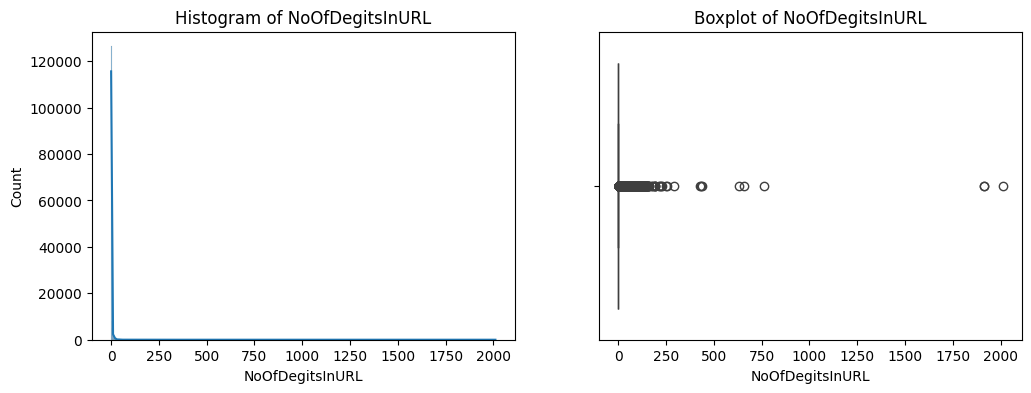

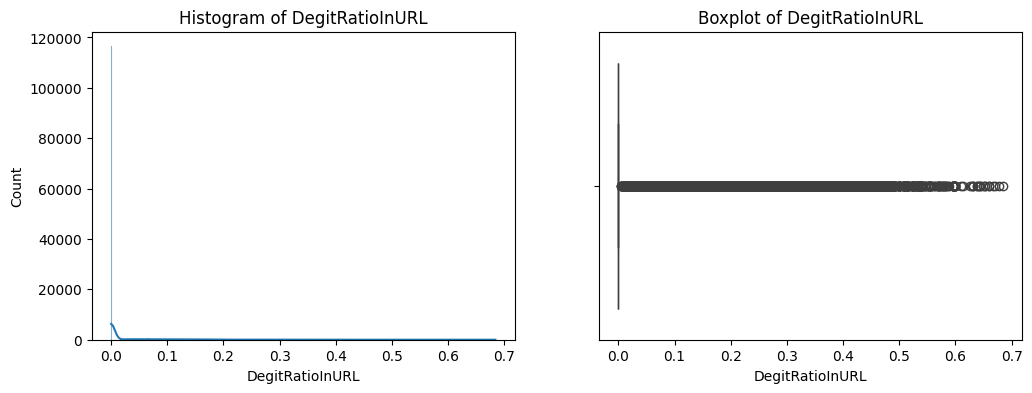

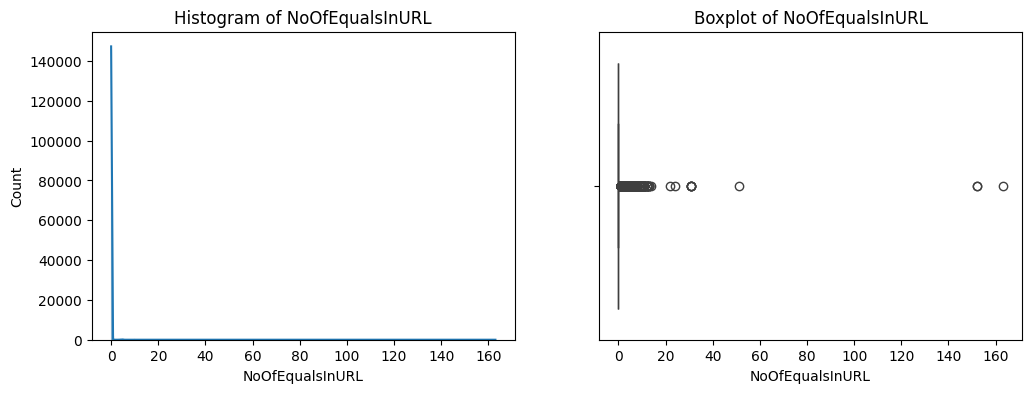

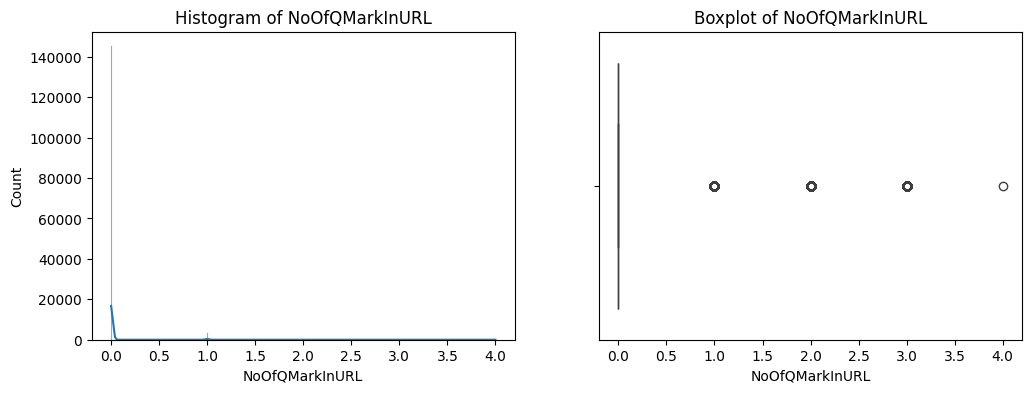

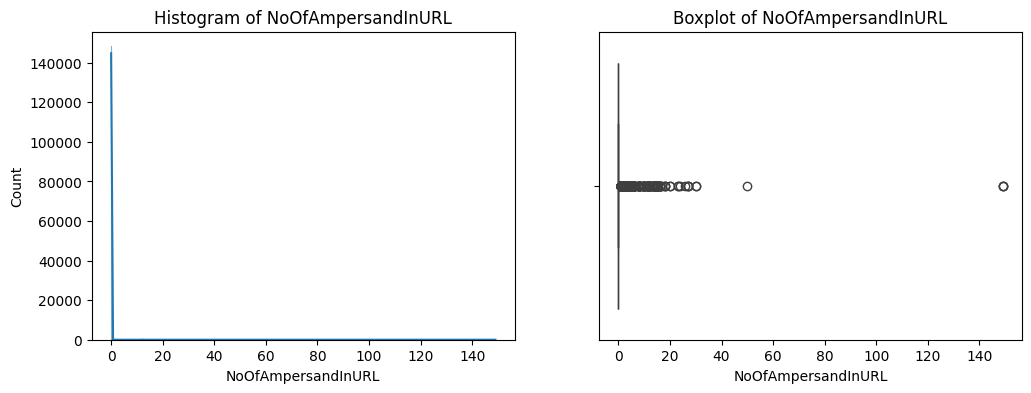

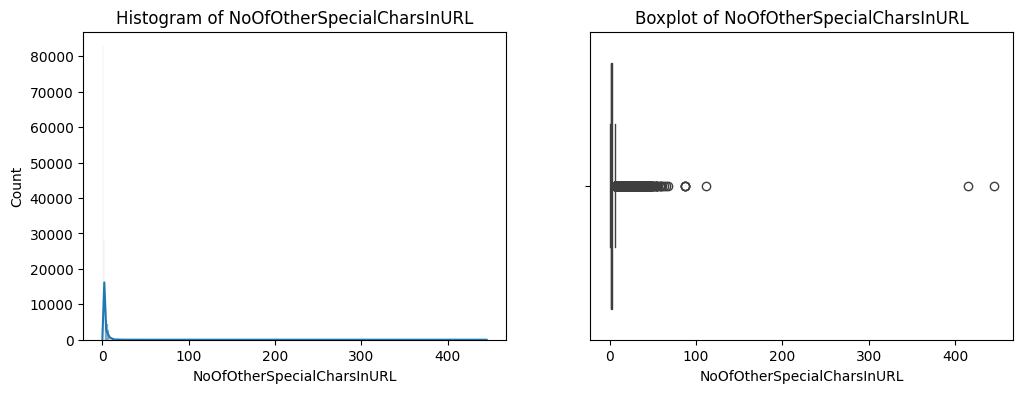

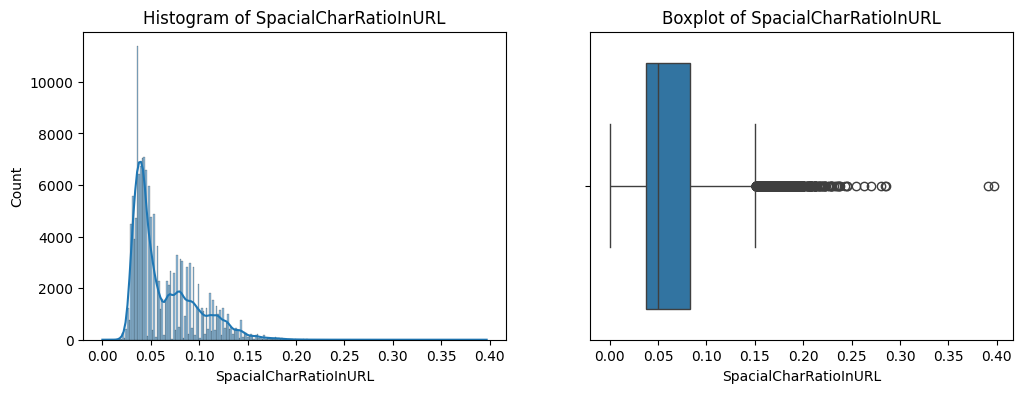

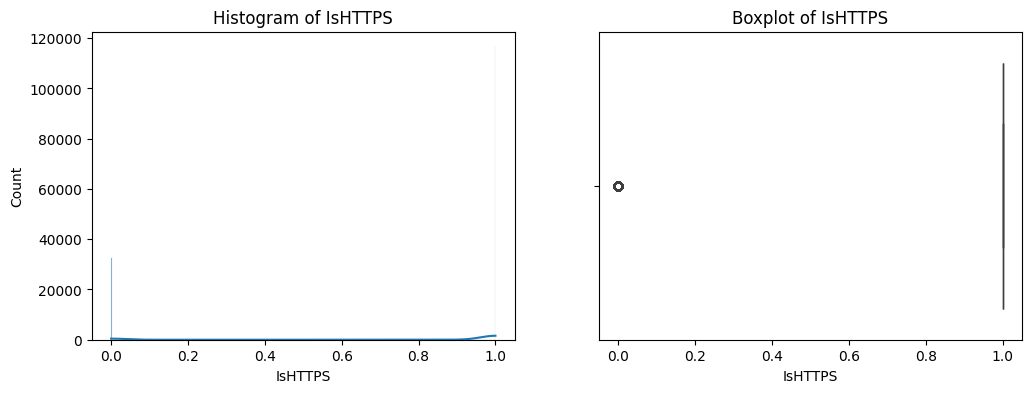

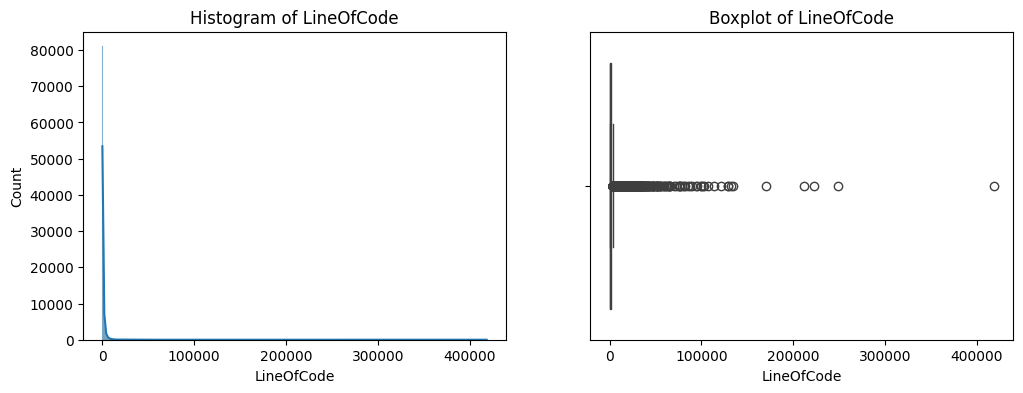

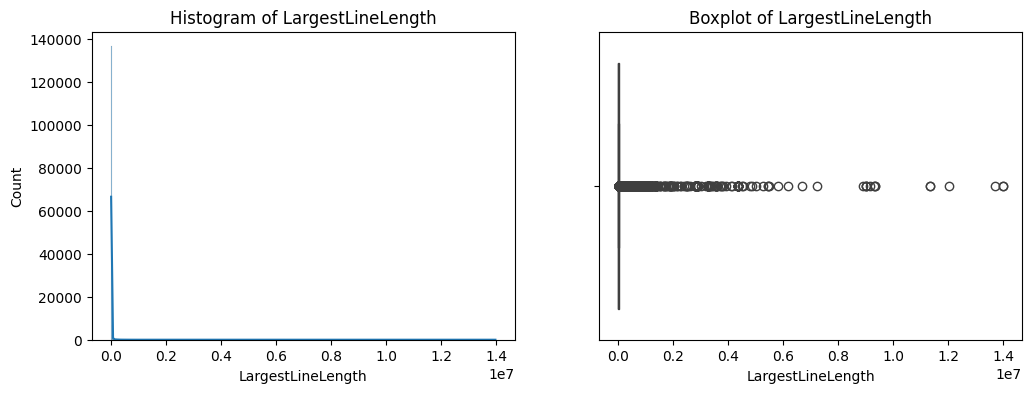

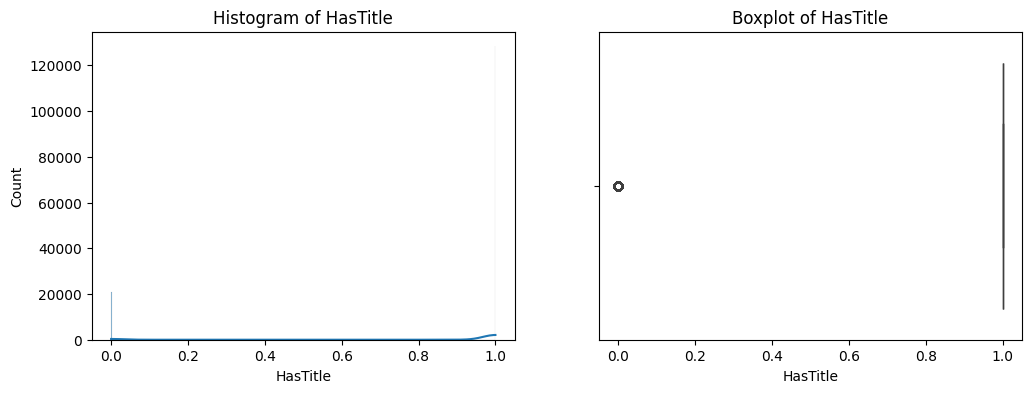

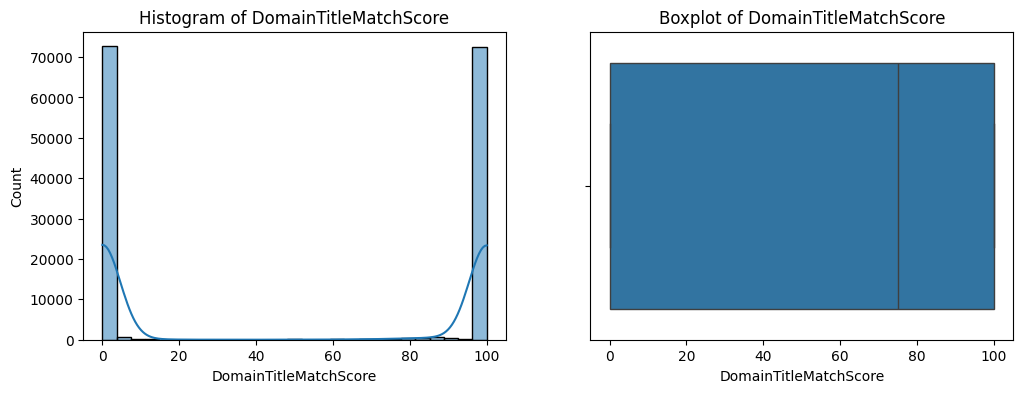

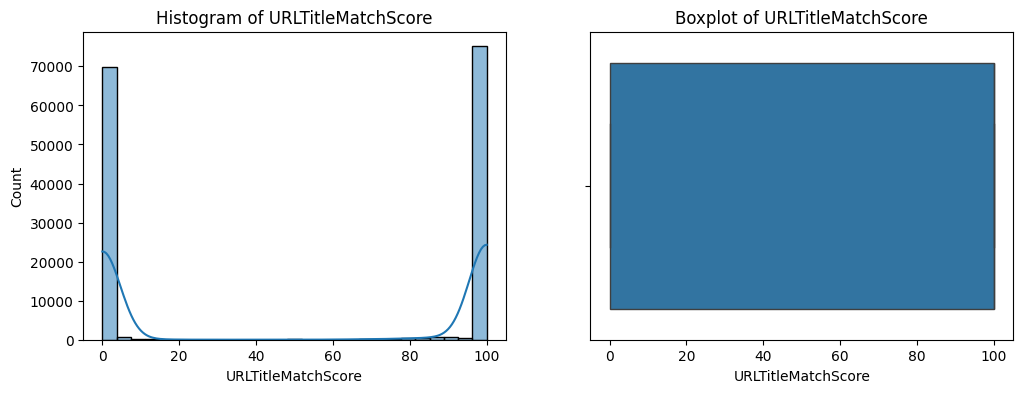

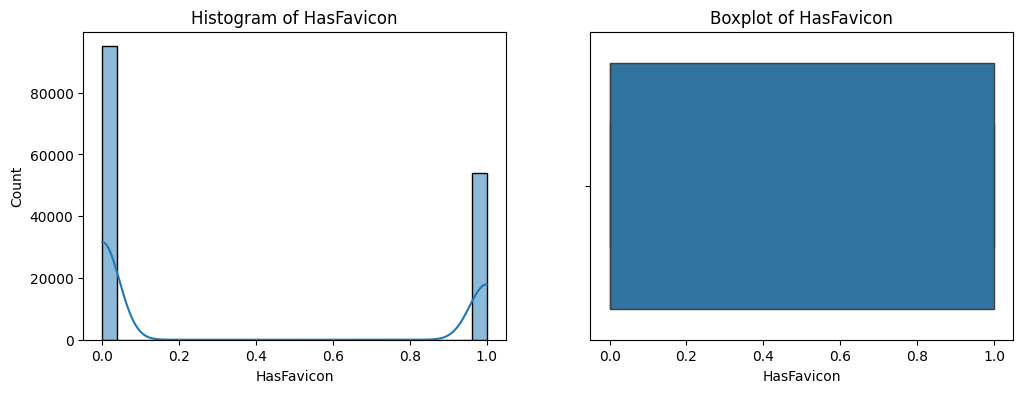

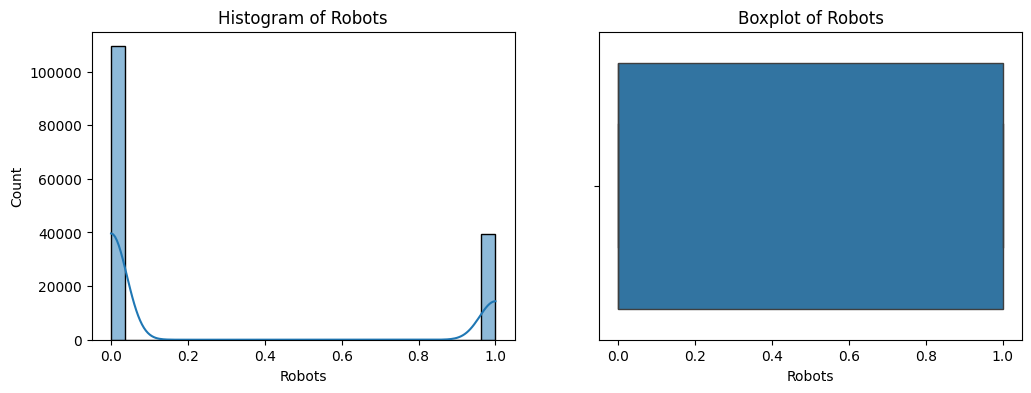

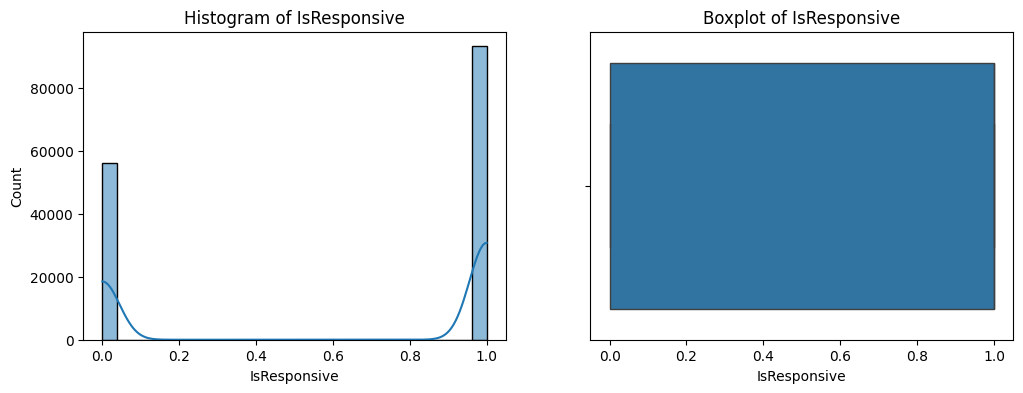

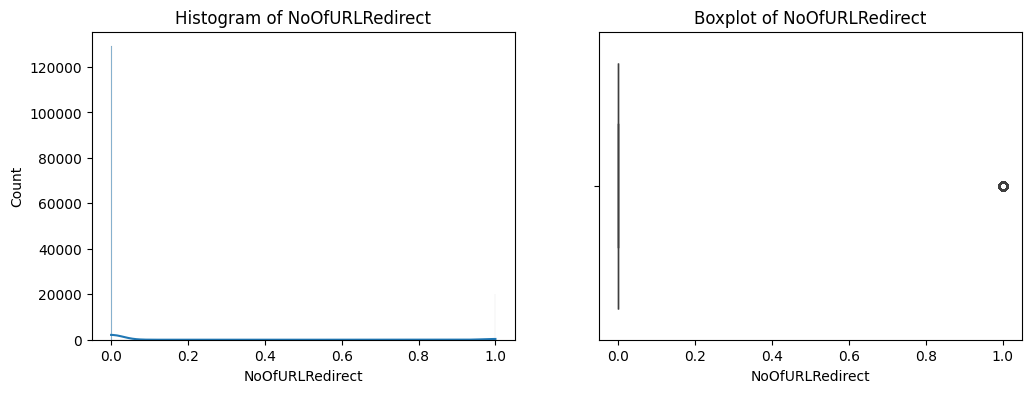

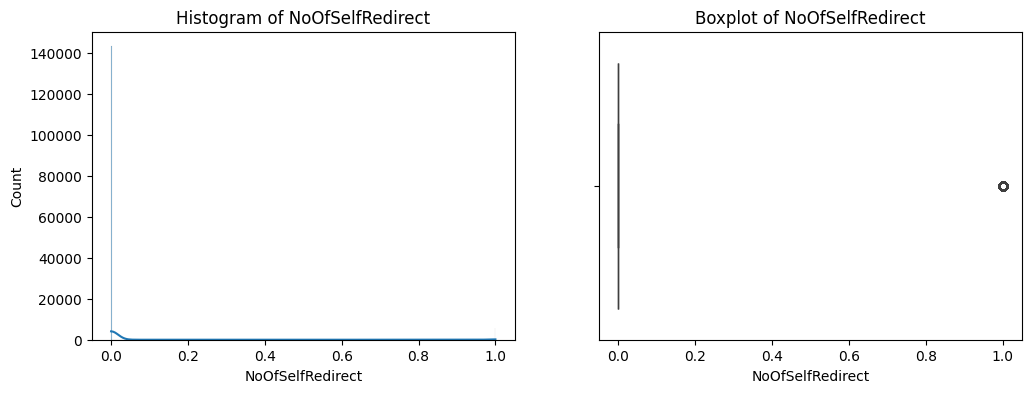

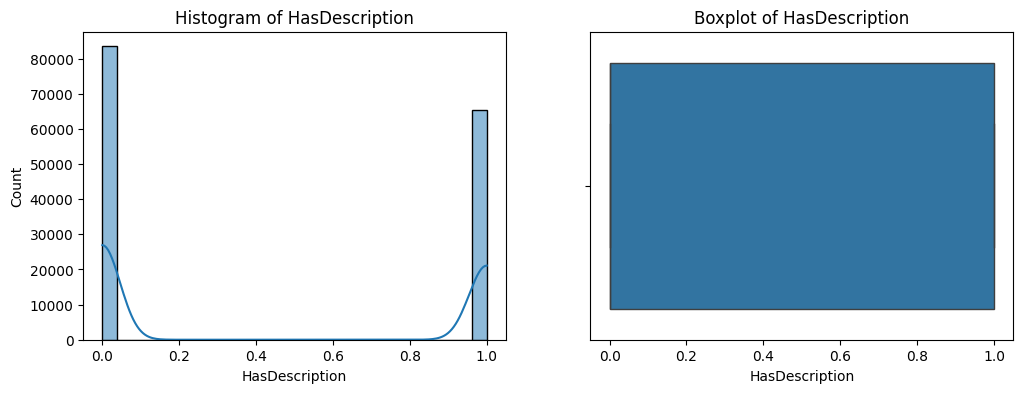

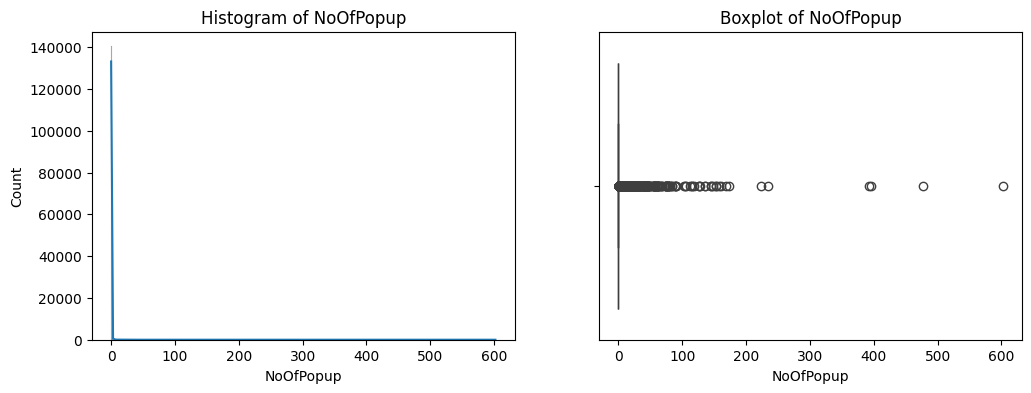

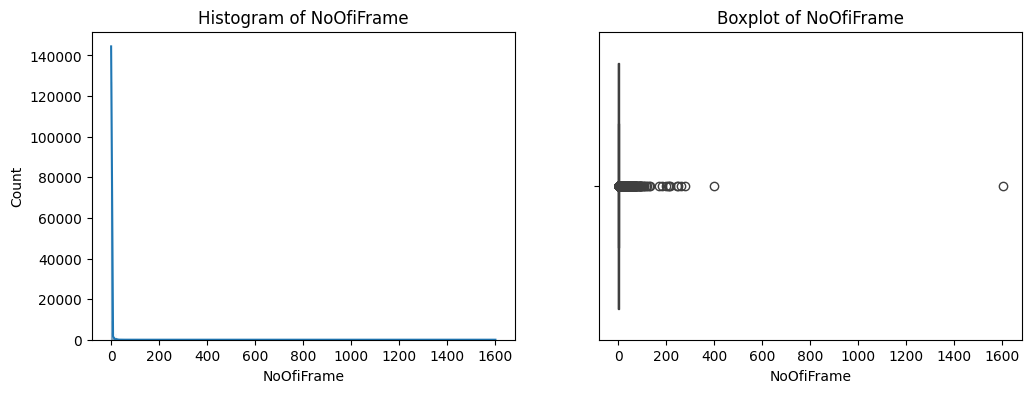

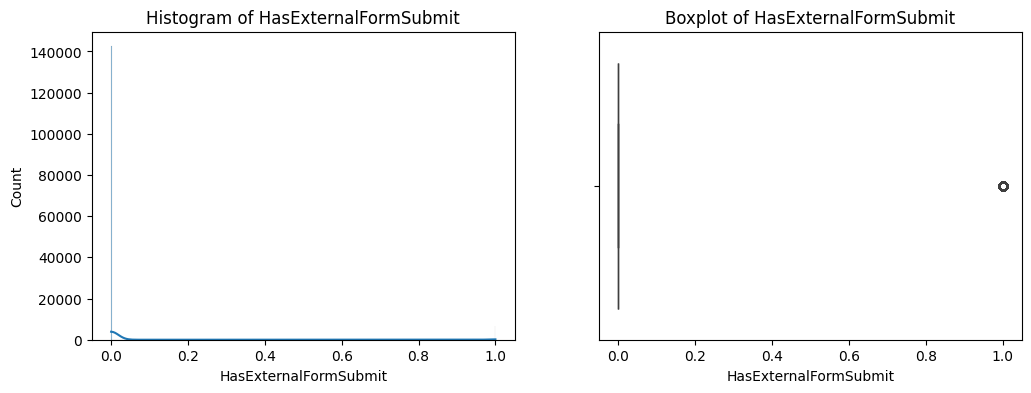

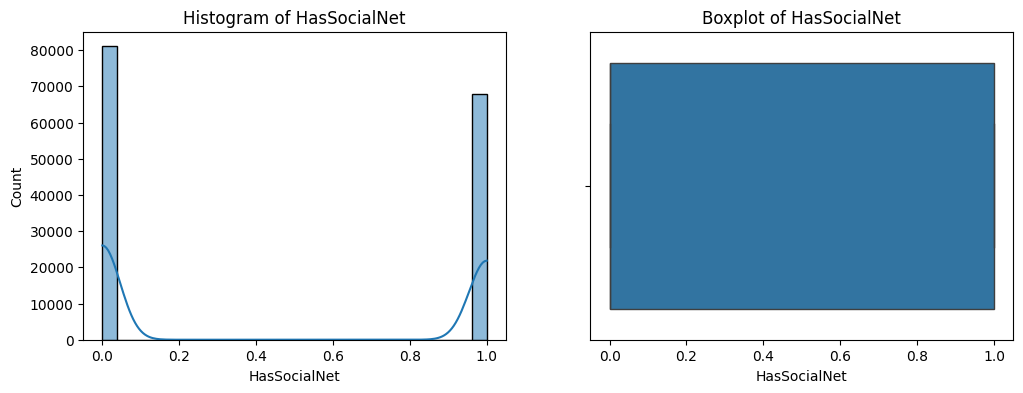

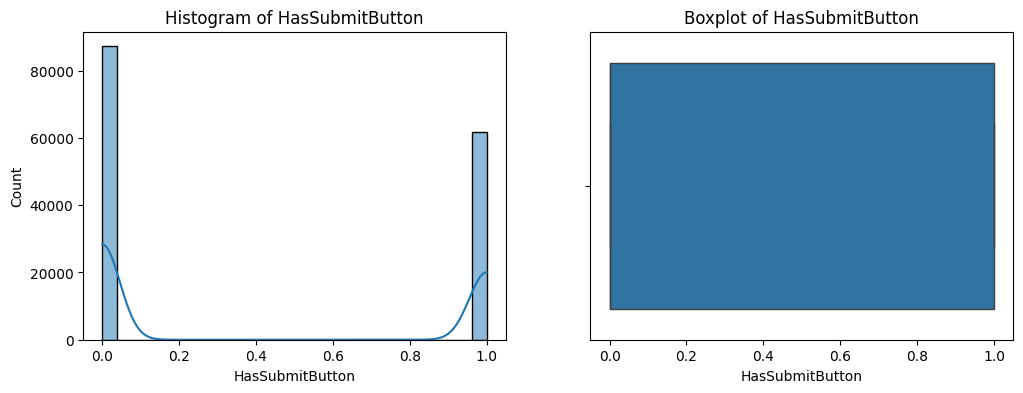

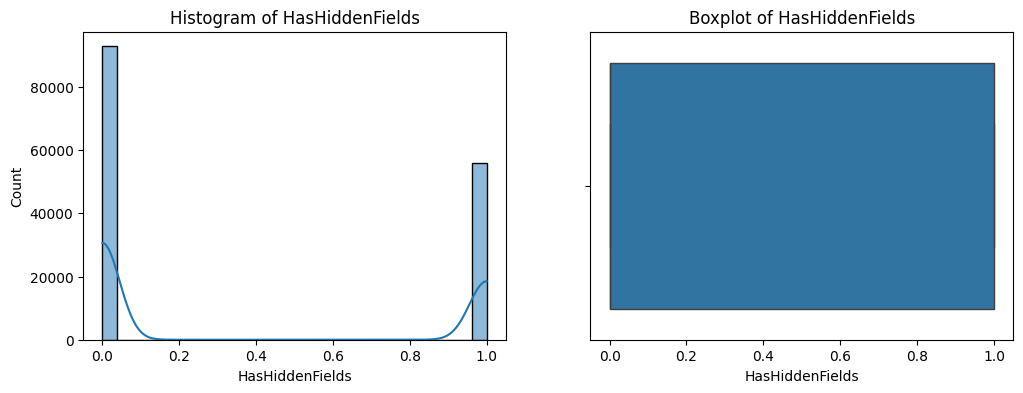

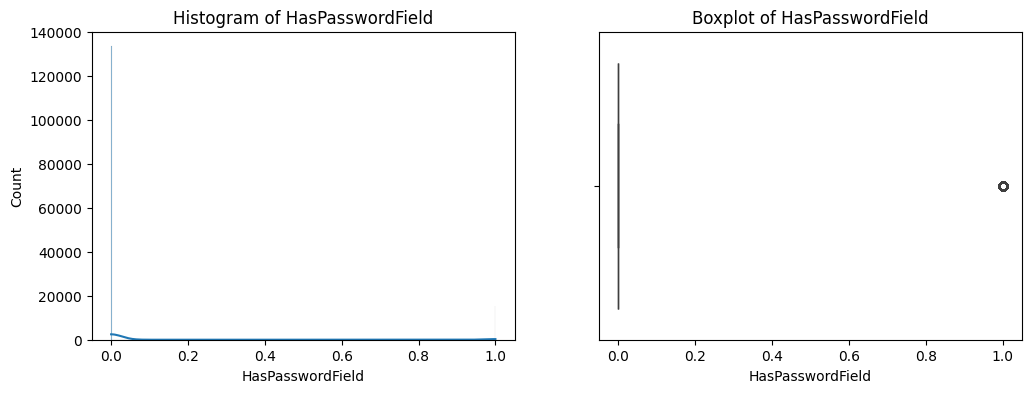

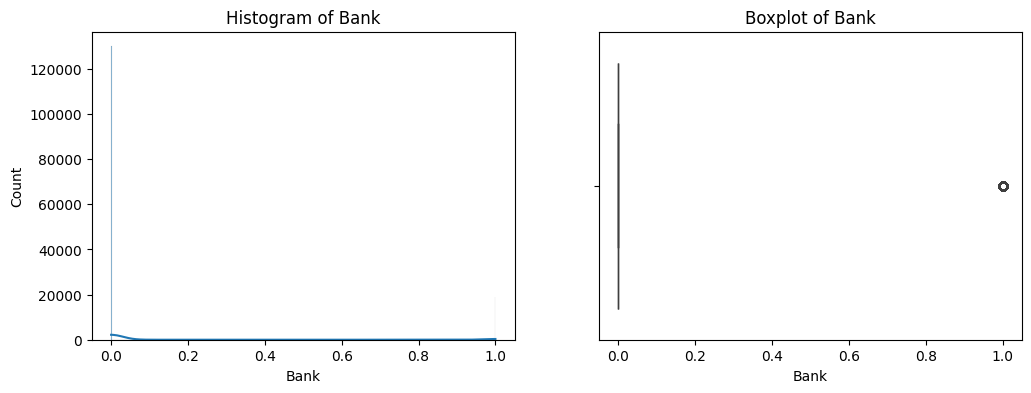

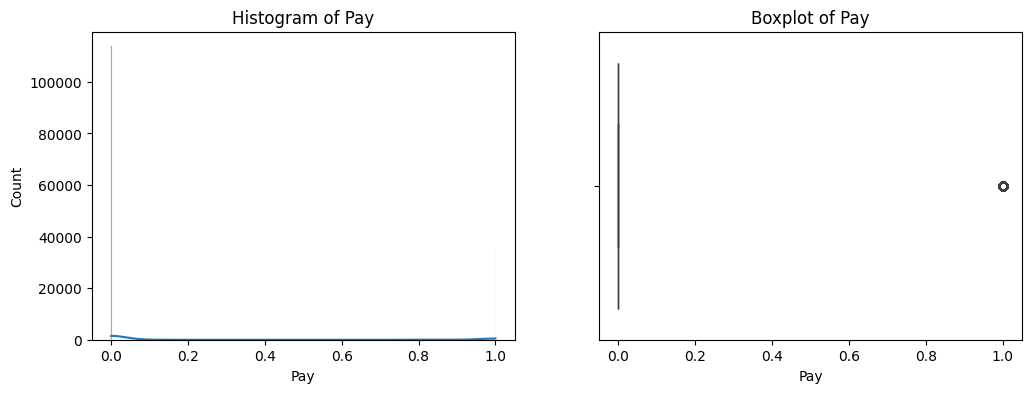

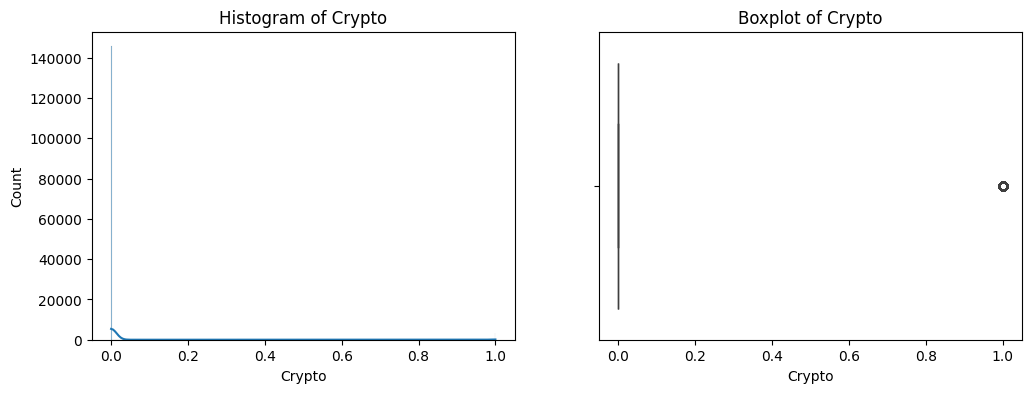

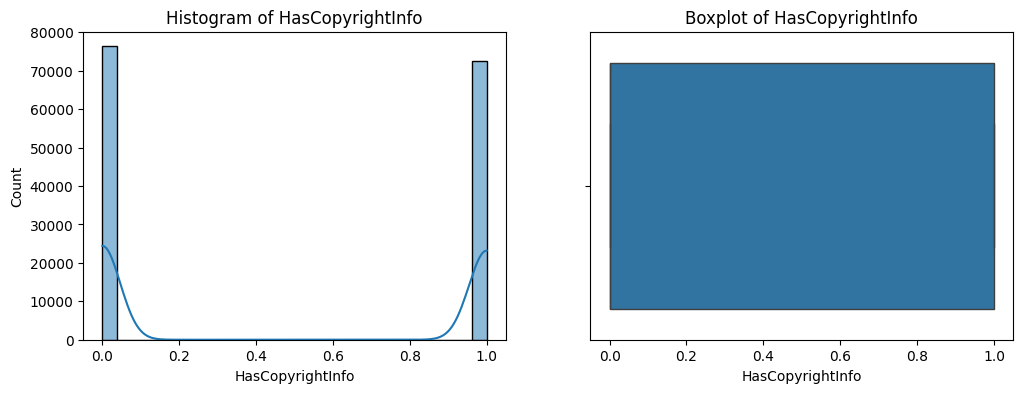

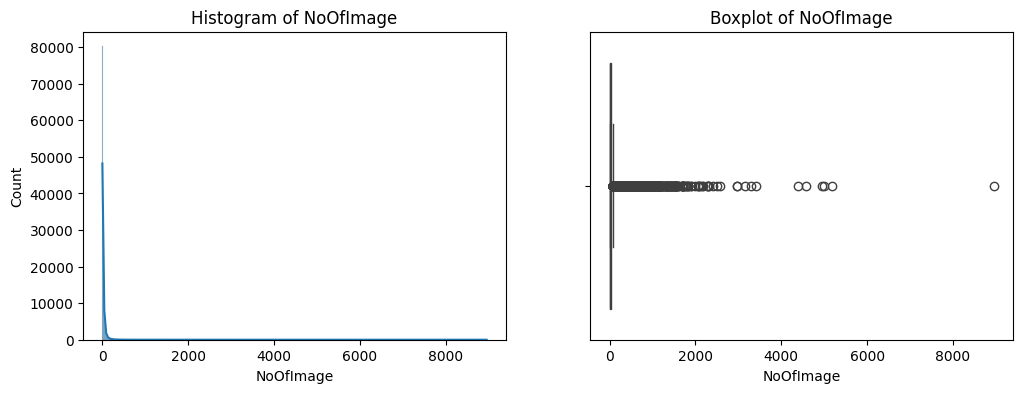

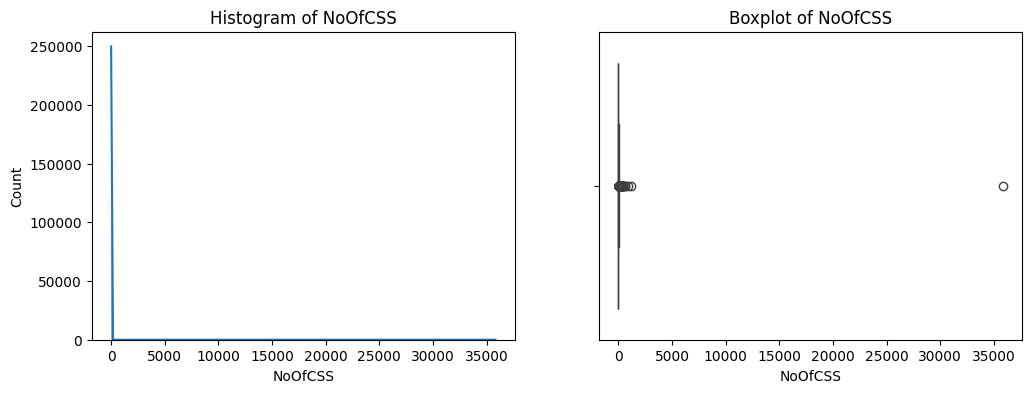

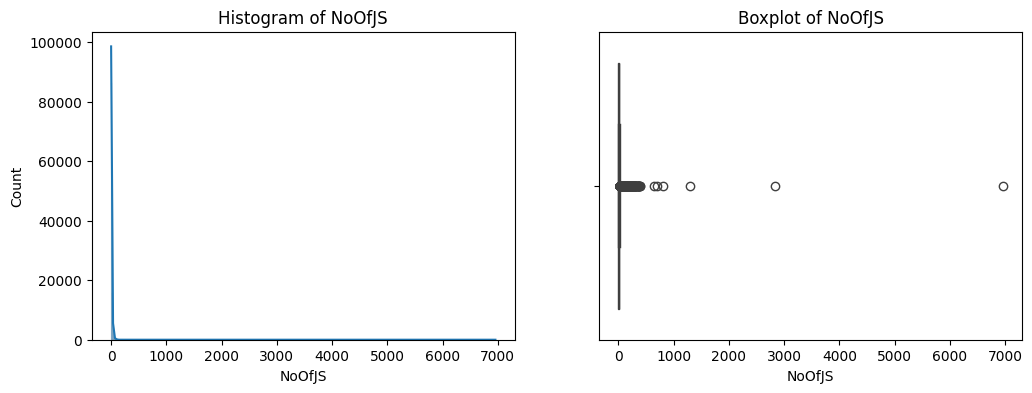

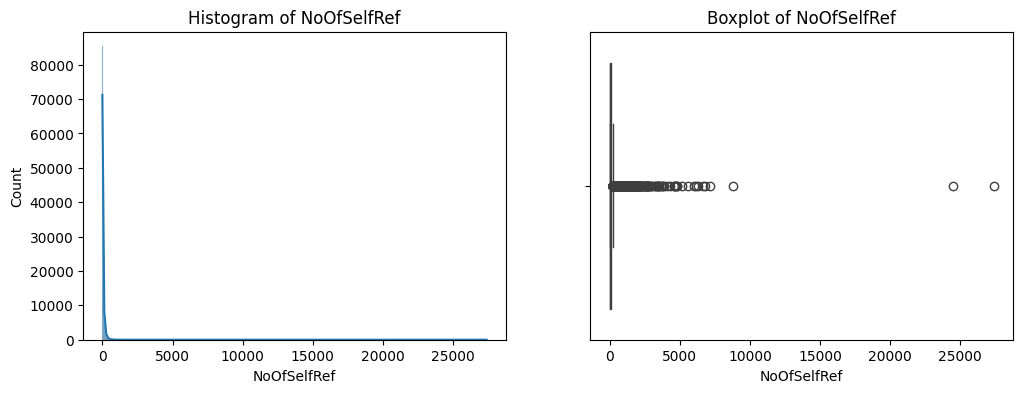

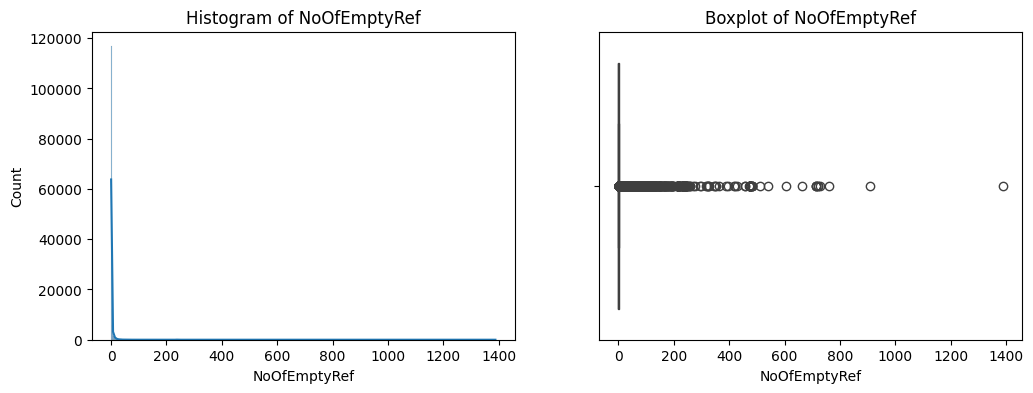

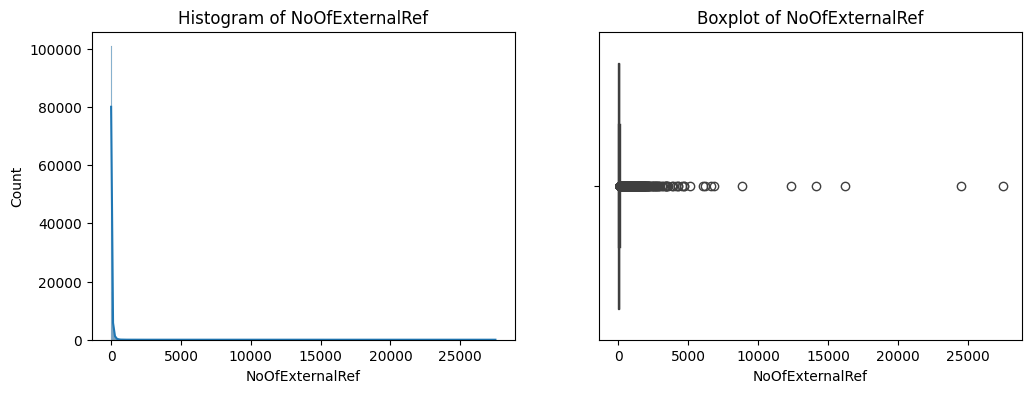

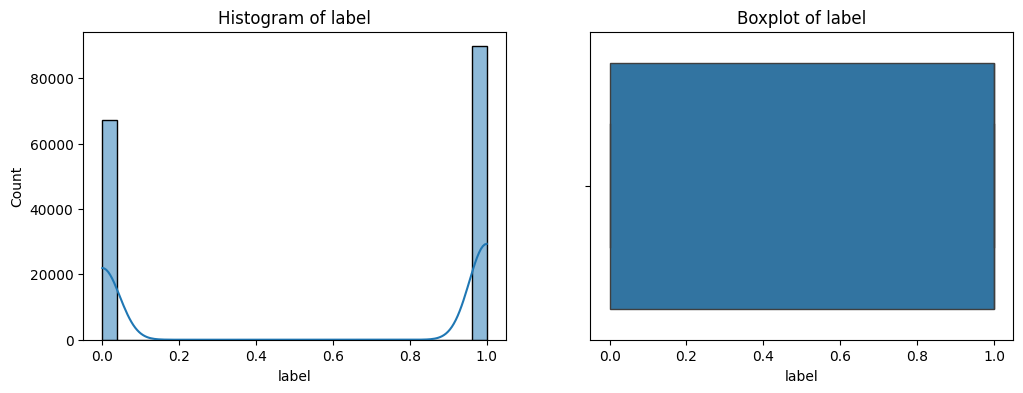

In [4]:
# Summary statistics for numerical columns
num_summary = df[num_cols].describe().T
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

I have outlier for almost every numeric column exsept binary column I need to change their type in feature eng part to arrange my data model.

well... I drop other 4 categorical data to clean my data bc of their are metadata not match or give meaningfull information to me. for my TLD categorical column we can see .com is dominationg the websites domains and follow by second and third most populer other is the sumation of under 100 frequency doamin expantion so variation of TDL a lot we can see that other categories are second most populer and third one .org for non-commercial intent and trust but we will examine how trust it is our future steps.

*Bivariate/Multivariate*

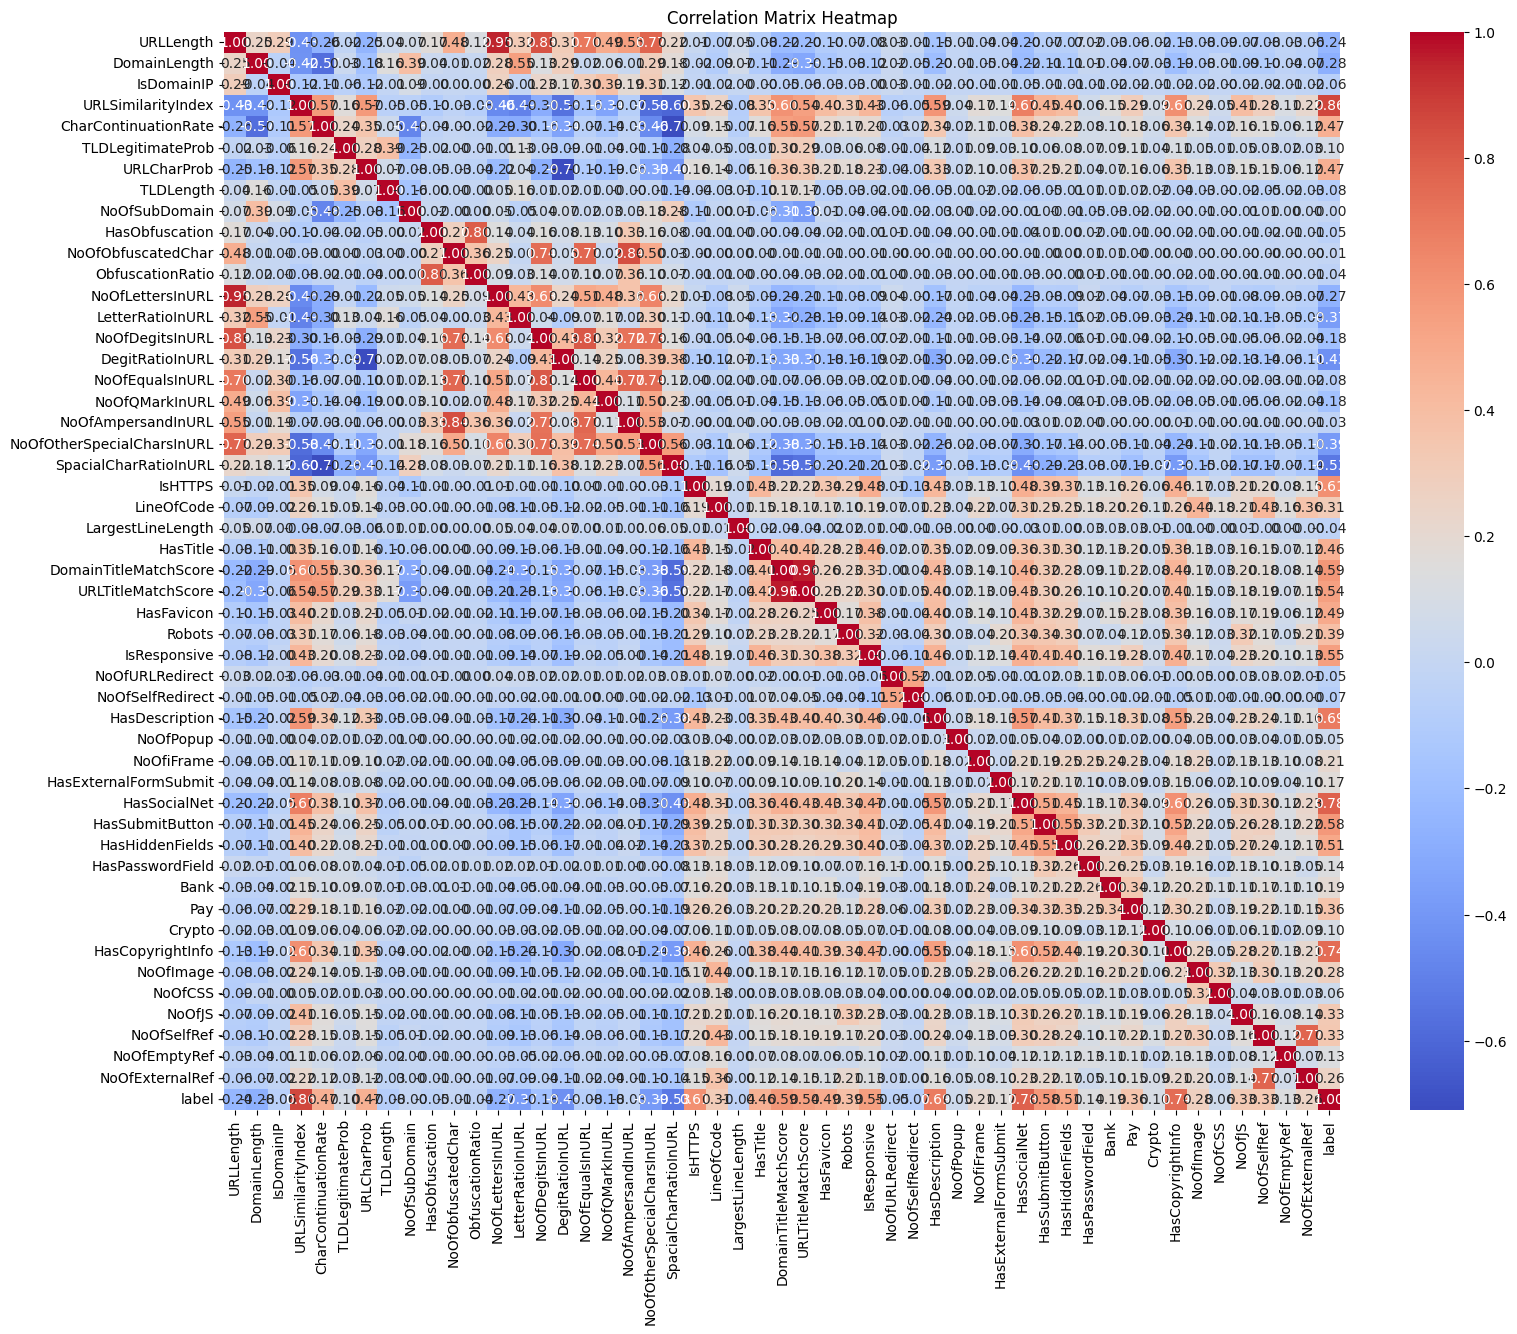

In [5]:
#corr matrix and heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

ther is a high related column to target variable 'label' positive and nevative also there is some positive correlation amount variabls. as a negative correlation spacialChainRatiolnURL observed...

In [ ]:
#categorical columns analysis ( do not run yet!)


ModuleNotFoundError: No module named 'statsmodels'

/var/folders/1y/vjrdcxhs2_l125ccbltlkq6h0000gn/T/ipykernel_1801/2660338468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_var, y=num_var, data=df, showfliers=False, palette="Set2")


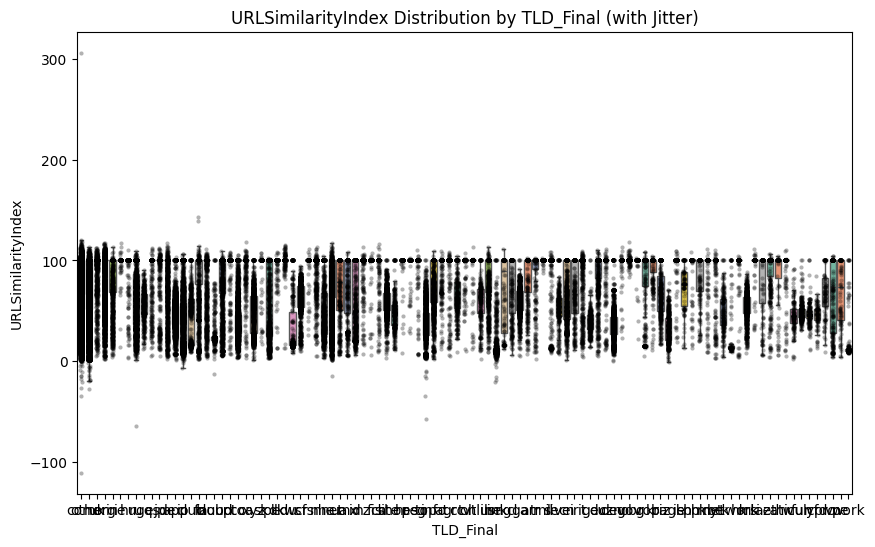

In [8]:
#boxplts with jitter
num_var = num_cols[3]  # change it here to any numerical variable you want to analyze
cat_var = cat_cols[0]  
plt.figure(figsize=(10, 6))

# 1. Create the Boxplot (Turn off outliers 'fliers' so they don't overlap with jitter)
sns.boxplot(x=cat_var, y=num_var, data=df, showfliers=False, palette="Set2")

# 2. Add Jitter (Strip plot)
sns.stripplot(x=cat_var, y=num_var, data=df, color='black', size=3, alpha=0.3, jitter=True)

plt.title(f"{num_var} Distribution by {cat_var} (with Jitter)")
plt.show()

Confirmatory Data Analysis

In [6]:
#TLD ve TLDLegitprob countin encoding hali mi?
import pandas as pd

# 1. Her TLD veri setinde kaç kere geçiyor? (Count)
tld_counts = df['TLD'].value_counts().reset_index()
tld_counts.columns = ['TLD', 'Count']

# 2. Her TLD'nin sahip olduğu Prob değerini alalım (Hepsi aynıdır diye varsayıyoruz, mean alalım)
tld_probs = df.groupby('TLD')['TLDLegitimateProb'].mean().reset_index()

# 3. İkisini birleştirelim
analiz_tablosu = pd.merge(tld_counts, tld_probs, on='TLD')

# 4. KONTROL: Count değeri AYNI olan ama Prob değeri FARKLI olan var mı?
# Aynı Count'a sahip gruplara bakalım
collision_check = analiz_tablosu.groupby('Count')['TLDLegitimateProb'].nunique()

print("--- ANALİZ SONUCU ---")
print(f"Toplam TLD Çeşidi Sayısı: {len(analiz_tablosu)}")
print(f"Count Değeri Çakışan Grup Sayısı: {len(collision_check[collision_check > 1])}")

if len(collision_check[collision_check > 1]) > 0:
    print("\n❌ SONUÇ: Bu bir COUNT ENCODING DEĞİL!")
    print("Kanıt: Aşağıdaki gruplarda TLD sayıları aynı olmasına rağmen Prob değerleri farklı:")
    print(collision_check[collision_check > 1].head())
else:
    print("\n✅ SONUÇ: Bu Count Encoding (veya onun türevi) olabilir.")
    print("Her count değerine karşılık tek bir Prob değeri atanmış.")

# 5. Gözle Kontrol (Örnek Tablo)
print("\n--- Gözle Kontrol Tablosu ---")
print(analiz_tablosu.sort_values(by='Count', ascending=False).head(10))

--- ANALİZ SONUCU ---
Toplam TLD Çeşidi Sayısı: 634
Count Değeri Çakışan Grup Sayısı: 45

❌ SONUÇ: Bu bir COUNT ENCODING DEĞİL!
Kanıt: Aşağıdaki gruplarda TLD sayıları aynı olmasına rağmen Prob değerleri farklı:
Count
1    77
2    57
3    37
4    33
5    20
Name: TLDLegitimateProb, dtype: int64

--- Gözle Kontrol Tablosu ---
   TLD  Count  TLDLegitimateProb
0  com  71057           0.522907
1  org  11880           0.079963
2  net   4560           0.038420
3  app   4090           0.001502
4   uk   4027           0.028555
5   co   3396           0.005977
6   io   2665           0.012927
7   de   2534           0.032650
8   ru   2460           0.018013
9   au   1845           0.010086


# DROP URLSimilarityIndex

In [9]:
#we need to check similarity index feature importance with a simple model 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY URLSimilarityIndex
X_simple = df[['URLSimilarityIndex']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY SimilarityIndex: {accuracy_score(y, clf.predict(X_simple)):.4f}") #woow this is too high

Accuracy with ONLY SimilarityIndex: 0.9755


# check other high correlation label feature to decide drop or not

In [10]:
# check the HasSocialNet.. to drop or not
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY HasSocialNetWord
X_simple = df[['HasSocialNet']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY HasSocialNet: {accuracy_score(y, clf.predict(X_simple)):.4f}")
#it is okey to keep HasSocialNet feature since lower than 0.9 accuracy

Accuracy with ONLY HasSocialNet: 0.8572


# normality check and transformation application